# FlowMLLab Week 15 - Complete Geometry-Generalization Laboratory

**Ehsan Roohi / FlowMLLab**

This notebook is the executable companion to the long-form Week 15 lecture. It combines theory, source provenance, split verification, learning-rate selection, independent metric recomputation, Reynolds-number failure analysis, and seven-row contour comparisons.

Scientific constraints:

- no CFD is generated here;
- no double-step motif is used in training or validation;
- g005 remains quarantined;
- the double-step test is historically inspected and all test conclusions are retrospective;
- company-inspired proxies are not presented as proprietary company models;
- unsuccessful vortices and negative ablations remain visible.

## 1. Reproducible setup

The notebook reads compact tables and figures from the checkout. For the full 342-field verification, download `FlowMLLab_Week15_PostAudit_LR_Sweep.zip` from the v1.8.0 Zenodo record, verify its frozen SHA-256, and unzip it beside the checkout or set `FLOWMLLAB_WEEK15_LR_DIR`. No CFD or retraining is performed.

In [1]:
from pathlib import Path
import sys, json, hashlib, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

import os
HERE=Path.cwd().resolve()
REPO=next((p for p in [HERE,*HERE.parents] if (p/'results/week15_postaudit').is_dir()),None)
if REPO is None: raise RuntimeError('Open this notebook from a complete FlowMLLab checkout.')
ROOT=REPO/'results/week15_postaudit'
FIGURES=ROOT
lr_env=os.environ.get('FLOWMLLAB_WEEK15_LR_DIR')
candidates=[Path(lr_env).expanduser() if lr_env else None,REPO.parent/'FlowMLLab_Week15_PostAudit_LR_Sweep',REPO.parent/'week15_lr_sweep_work']
LR=next((p.resolve() for p in candidates if p is not None and (p/'runs/protocol.json').is_file()),None)
if LR is None:
    raise FileNotFoundError('Download FlowMLLab_Week15_PostAudit_LR_Sweep.zip from https://doi.org/10.5281/zenodo.22840293, unzip it beside the checkout, or set FLOWMLLAB_WEEK15_LR_DIR.')
ARCHIVE=LR/'archive_input'
if not ARCHIVE.is_dir(): raise FileNotFoundError(f'Missing archive_input inside {LR}')
sha=lambda p: hashlib.sha256(Path(p).read_bytes()).hexdigest()
sys.path.insert(0,str(ARCHIVE/'qa'))
sys.path.insert(0,str(LR/'experiment'))
from week15_diverse_author_protocol import Dataset
from metrics_indep import metrics, reverse_components
d=Dataset(True)
print('Repository located; using results/week15_postaudit.')
print('LR evidence located:',LR.name)
print('Dataset SHA-256:',sha(ARCHIVE/'results/step_operator_audit/source/dataset.npz'))

Repository located; using results/week15_postaudit.
LR evidence located: FlowMLLab_Week15_PostAudit_LR_Sweep
Dataset SHA-256: 28d4d4c440cdc4c1ac1d13749ce00b0690d99f29cf20fd56c65fc00b6a8058fd


## 2. Neural-operator map

| Method | Geometry input | Field-query mechanism | Evidence status |
|---|---|---|---|
| Ordinary DeepONet | incomplete/implicit geometry | branch-trunk contraction | historical baseline |
| Geom-DeepONet | raster SDF and local query geometry | geometry/output networks + contraction | pinned author implementation/adaptation |
| Geo-FNO | deformed grid representation | spectral operator | historical baseline |
| SMART | sampled boundary to latent geometry | cross-attentive query decoder | pinned academic author code |
| GeoTransolver | multiscale geometry neighborhoods | physical-state slices + GALE | pinned PhysicsNeMo code |
| DoMINO | boundary/SDF on auxiliary geometry grids | global/local basis aggregation | pinned PhysicsNeMo code; planar adapter |
| PhysicsX-inspired | weighted sampled geometry context | independent query decoder | transparent proxy |
| LIFT-inspired | context proxy plus wall distance | independent query decoder | transparent proxy |

Primary links: [DeepONet](https://github.com/lululxvi/deeponet), [Geom-DeepONet](https://github.com/ncsa/GeomDeepONet/tree/0a65f3d5b133fb6f248b0b11caa970d0cd724fb5), [neuraloperator](https://github.com/neuraloperator/neuraloperator), [Geo-FNO](https://github.com/neuraloperator/Geo-FNO), [SMART](https://github.com/jhagnberger/smart/tree/9e9b30e6bd8b76b993643542300d9ee7a1e0beb5), [Transolver](https://github.com/thuml/Transolver), [PhysicsNeMo GeoTransolver](https://github.com/NVIDIA/physicsnemo/tree/94dbdf829d1a4e93e3f31ecb77713392c471388e/physicsnemo/models/geotransolver), and [PhysicsNeMo DoMINO](https://github.com/NVIDIA/physicsnemo/tree/94dbdf829d1a4e93e3f31ecb77713392c471388e/physicsnemo/models/domino).

## 3. Split reconstruction from the actual masks

We do not trust a filename such as `train` or `test` by itself. We check case identities, geometry grouping, and the two-drop motif directly from mask floor profiles.

In [2]:
protocol=json.load(open(LR/'runs/protocol.json'))
assert sha(ARCHIVE/'results/step_operator_audit/source/dataset.npz')==protocol['dataset']['dataset_sha256']
for group,n in [('train',100),('validation',8),('test',19)]:
    assert list(map(int,d.groups[group]))==protocol['dataset']['cases'][group]
    assert len(d.groups[group])==n

def has_two_drop_motif(case):
    floor=np.argmax(d.masks[int(case)].reshape(60,300),axis=0)
    delta=np.diff(floor); drops=np.where(delta<=-5)[0]
    return any(not np.any(delta[a+1:b+1]>0) for a,b in zip(drops,drops[1:]))

assert not any(has_two_drop_motif(i) for i in np.r_[d.groups['train'],d.groups['validation']])
assert all(has_two_drop_motif(i) for i in d.groups['test'])
assert protocol['dataset']['quarantine_cases']==[11,12,13]
assert all(has_two_drop_motif(i) for i in protocol['dataset']['quarantine_cases'])
pd.DataFrame({
 'partition':['train','validation','retrospective test','quarantine'],
 'cases':[100,8,19,3],
 'geometry_ids':[len(set(d.gids[d.groups['train']])),len(set(d.gids[d.groups['validation']])),len(set(d.gids[d.groups['test']])),1]
})

,partition,cases,geometry_ids
0,train,100,39
1,validation,8,3
2,retrospective test,19,8
3,quarantine,3,1


## 4. Training geometry coverage

The first visual question is not “which prediction looks best?” It is “what did the network have an opportunity to learn?” The selected strip spans expansion/contraction, obstacle, single-step, and ramp examples. The critical gap remains: no Re=25 single-step case below 0.5H exists in training.

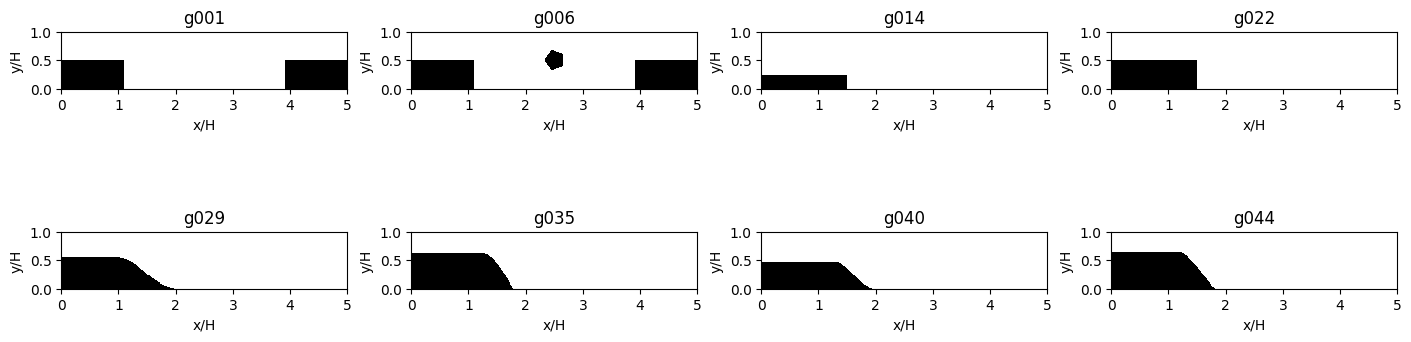

In [3]:
training_ids=[1,6,14,22,29,35,40,44]
fig,axes=plt.subplots(2,4,figsize=(14,4),constrained_layout=True)
for ax,g in zip(axes.flat,training_ids):
    ci=next(int(i) for i in d.groups['train'] if int(d.gids[i])==g)
    ax.imshow(d.masks[ci].reshape(60,300),origin='lower',extent=(0,5,0,1),cmap='gray',vmin=0,vmax=1,aspect='equal',interpolation='nearest')
    ax.set(title=f'g{g:03d}',xlabel='x/H',ylabel='y/H',xlim=(0,5),ylim=(0,1))
plt.show()

## 5. Metrics

Velocity and vorticity are field metrics; centered pressure removes the arbitrary additive gauge. Reverse IoU uses \(u<-0.01\), four-connectivity, and an eight-cell component filter. Reverse-region velocity error is measured over CFD reverse cells and reveals amplitude errors that binary IoU hides.

In [4]:
print('Physical spacing: dx/H =',5/300,'dy/H =',1/60)
print('Retained keys:', ['velocity_percent','pressure_percent','vorticity_percent','reverse_iou_u_lt_minus_001','reverse_velocity_percent'])

Physical spacing: dx/H = 0.016666666666666666 dy/H = 0.016666666666666666
Retained keys: ['velocity_percent', 'pressure_percent', 'vorticity_percent', 'reverse_iou_u_lt_minus_001', 'reverse_velocity_percent']


## 6. Complete global comparison

Rows intentionally mix three protocol classes, which remain explicitly labeled. Historical results are context; LR-tuned rows are the new validation-selected comparison; GeoTransolver and the proxies retain the matched-budget LAST protocol.

In [5]:
table=pd.read_csv(ROOT/'consolidated_results.csv')
display(table.style.format({
 'velocity_percent':'{:.2f}','pressure_percent':'{:.2f}','vorticity_percent':'{:.2f}',
 'reverse_iou_u_lt_minus_001':'{:.3f}','reverse_velocity_percent':'{:.1f}'
}))

,model,code_status,protocol,peak_lr,velocity_percent,pressure_percent,vorticity_percent,reverse_iou_u_lt_minus_001,reverse_velocity_percent
0,Historical ordinary DeepONet,historical bundled result,historical checkpoint; seed 17,historical,14.45,44.00,29.67,0.376,165.5
1,Historical Geom-DeepONet,historical bundled result,historical checkpoint; seed 17,historical,9.86,36.22,15.71,0.356,147.5
2,Historical Geo-FNO,historical bundled result,historical checkpoint; seed 17,historical,15.85,62.02,29.41,0.369,299.2
3,LR-tuned Geom-DeepONet,author code / verified adapter,"validation-selected BEST; 3 seeds; 19,200-update ceiling",0.001,10.53,32.71,17.40,0.464,127.6
4,LR-tuned academic SMART,author code / verified adapter,"validation-selected BEST; 3 seeds; 19,200-update ceiling",0.001,11.61,53.11,21.53,0.503,200.7
5,LR-tuned DoMINO planar,author code / verified adapter,"validation-selected BEST; 3 seeds; 19,200 updates",0.001,15.59,71.85,22.73,0.534,166.0
6,Matched GeoTransolver,author code / verified adapter,"matched-budget LAST; 3 seeds; 19,200 updates",0.0003,24.98,111.81,31.52,0.300,160.6
7,PhysicsX-inspired proxy,transparent idea proxy; not proprietary code,"matched-budget LAST; 3 seeds; 19,200 updates",0.0003,40.63,263.69,65.70,0.324,265.8
8,LIFT wall-feature proxy,transparent idea proxy; not proprietary code,"matched-budget LAST; 3 seeds; 19,200 updates",0.0003,41.78,283.90,52.17,0.332,197.6


### Reading the table

- Historical Geom has the smallest global velocity and vorticity errors.
- Tuned Geom is the best newly comparable model for global field reconstruction.
- Tuned DoMINO has the highest reverse IoU.
- The two proxies are negative transfer results, not demonstrations of the proprietary systems.
- Pressure and reverse-region velocity error prevent a flattering IoU-only interpretation.

## 7. Validation-only learning-rate sweep

All three author-code candidates were trained at peak learning rates 1e-3, 3e-4, and 1e-4, with three seeds and a 19,200-update ceiling. Selection reads no double-step arrays.

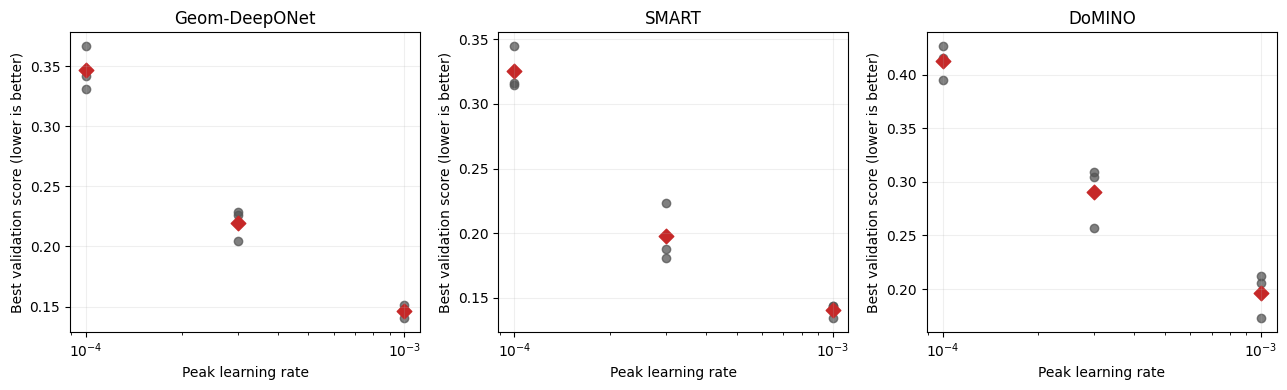

{'geom_author_fresh': {'0.001': 0.1462373028647089,
  '0.0003': 0.2198835724491085,
  '0.0001': 0.34642847412479966},
 'smart_author': {'0.001': 0.14021576356964127,
  '0.0003': 0.1973891476762183,
  '0.0001': 0.32527541950373223},
 'domino_author': {'0.001': 0.19671235497670084,
  '0.0003': 0.29032156536380777,
  '0.0001': 0.4123483745792971}}

In [6]:
freeze=json.load(open(LR/'runs/frozen_selection.json'))
records=freeze['all_validation_records']; models=['geom_author_fresh','smart_author','domino_author']; names=['Geom-DeepONet','SMART','DoMINO']
fig,axes=plt.subplots(1,3,figsize=(13,4))
for ax,m,name in zip(axes,models,names):
    for rate in [1e-4,3e-4,1e-3]:
        vals=[r['best_validation']['geometry_mean']['score'] for r in records if r['model']==m and np.isclose(r['peak_lr'],rate)]
        ax.scatter([rate]*3,vals,color='#555',alpha=.75);ax.scatter([rate],[np.mean(vals)],marker='D',s=55,color='#c62828')
        np.testing.assert_allclose(np.mean(vals),freeze['lr_validation_score_means'][m][str(rate)],rtol=1e-6,atol=1e-6)
    ax.set_xscale('log');ax.set(title=name,xlabel='Peak learning rate',ylabel='Best validation score (lower is better)');ax.grid(alpha=.2)
plt.tight_layout();plt.show()
freeze['lr_validation_score_means']

## 8. Check paired initialization and sampling

A learning-rate sweep is interpretable only if each model/seed begins from the same initialization and sees the same sampled training entries across learning rates.

In [7]:
for model in models:
    subset=[r for r in records if r['model']==model]
    for seed in [17,29,43]:
        paired=[r for r in subset if r['seed']==seed]
        assert len({r['initial_weights_sha256'] for r in paired})==1
        assert len({r['sampling_sha256'] for r in paired})==1
print('Paired initialization and sampling hashes verified for 9 model/seed groups.')

Paired initialization and sampling hashes verified for 9 model/seed groups.


## 9. Reverse-scale ablation

The common physical u/v scale improves validation velocity and pressure but worsens the declared score and reverse IoU. It therefore fails its frozen gate and is not evaluated on the double-step set.

In [8]:
final=json.load(open(LR/'runs/final_selection.json'))
pd.DataFrame([final['baseline_validation_means'],final['candidate_validation_means']],index=['retained','common reverse scale'])[['score','velocity_percent','pressure_percent','reverse_iou_u_lt_minus_001']].style.format('{:.4f}')

,score,velocity_percent,pressure_percent,reverse_iou_u_lt_minus_001
retained,0.1462,4.4532,10.1600,0.7603
common reverse scale,0.1501,4.1162,9.5984,0.7349


## 10. Independent recomputation of all 342 tuned prediction fields

This is the central evidence cell. It verifies each NPZ hash, mask, coordinate array, CFD truth array, and five metrics using the independent float64 implementation. Tolerance is 1e-6, not the nonportable 1e-9 used in an earlier notebook.

In [9]:
all_records=json.load(open(LR/'report/all_case_records.json'));assert len(all_records)==342
keys=['velocity_percent','pressure_percent','vorticity_percent','reverse_iou_u_lt_minus_001','reverse_velocity_percent'];maxdiff={k:0. for k in keys}
for r in all_records:
    p=LR/r['path'];assert sha(p)==r['sha256']
    with np.load(p,allow_pickle=False) as z:
        ci=int(z['row_index']);np.testing.assert_array_equal(z['mask'],d.masks[ci]);np.testing.assert_array_equal(z['coordinates'],d.xy[ci]);np.testing.assert_allclose(z['truth'],d.truth(ci),rtol=1e-6,atol=1e-6)
        got=metrics(d.truth(ci),z['prediction'],d.masks[ci])
    for k in keys:
        maxdiff[k]=max(maxdiff[k],abs(got[k]-r[k]));np.testing.assert_allclose(got[k],r[k],rtol=1e-6,atol=1e-6)
print('Verified fields:',len(all_records));print('Maximum differences:',maxdiff)

Verified fields: 342
Maximum differences: {'velocity_percent': 3.907985046680551e-14, 'pressure_percent': 5.684341886080802e-14, 'vorticity_percent': 1.4210854715202004e-14, 'reverse_iou_u_lt_minus_001': 0.0, 'reverse_velocity_percent': 0.0}


## 11. Reynolds-number stratification

Overall velocity averages hide the failure mechanism. Reverse IoU changes dramatically with Reynolds number because the low-step/Re=25 combination is absent from training.

In [10]:
summary=json.load(open(LR/'report/summary.json'))['states']['best'];hist=json.load(open(LR/'report/historical_context.json'))
re=[25,50,100]
series={'Historical Geom':[np.mean([x['reverse_iou_u_lt_minus_001'] for x in hist if x['model']=='geom' and x['Re']==v]) for v in re]}
for m,name in zip(models,names):series[name]=[summary[m]['by_Re'][str(v)]['reverse_iou_u_lt_minus_001'] for v in re]
pd.DataFrame(series,index=re).rename_axis('Re').style.format('{:.3f}')

,Historical Geom,Geom-DeepONet,SMART,DoMINO
Re,,,,
25,0.096,0.261,0.299,0.357
50,0.477,0.560,0.604,0.607
100,0.628,0.673,0.710,0.730


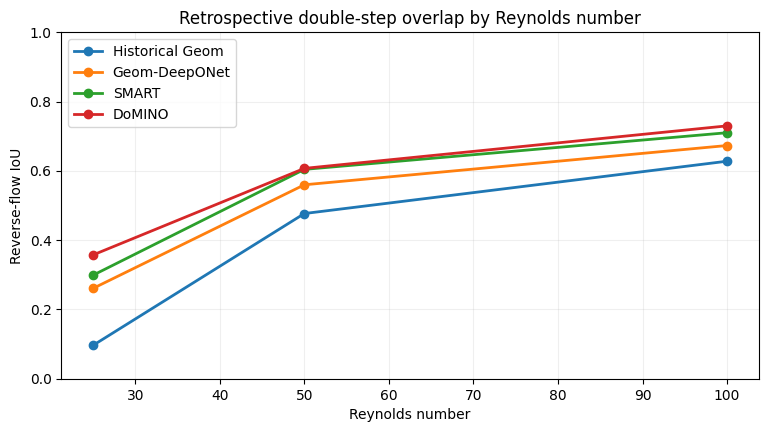

In [11]:
fig,ax=plt.subplots(figsize=(9,4.5))
for name,vals in series.items():ax.plot(re,vals,marker='o',lw=2,label=name)
ax.set(xlabel='Reynolds number',ylabel='Reverse-flow IoU',ylim=(0,1),title='Retrospective double-step overlap by Reynolds number');ax.grid(alpha=.2);ax.legend();plt.show()

## 12. Component-level diagnosis at g051/Re25

We compare component sizes and bounds rather than relying only on a streamline impression.

In [12]:
case='g051_Re25';ci=next(int(i) for i in d.groups['test'] if f'g{d.gids[i]:03d}_Re{int(d.re[i])}'==case);mask=d.masks[ci].reshape(60,300);truth=d.truth(ci).reshape(60,300,3)
tm,tc=reverse_components(truth[:,:,0],mask)
rows=[{'field':'CFD','components':len(tc),'cells':int(tm.sum()),'bounds':tc}]
for model,name in zip(models,names):
    sel=next(x for x in final['selected'] if x['model']==model and x['seed']==17);p=LR/sel['run']/'best_predictions'/f'{case}.npz';pred=np.load(p)['prediction'].reshape(60,300,3);pm,pc=reverse_components(pred[:,:,0],mask)
    rows.append({'field':name,'components':len(pc),'cells':int(pm.sum()),'bounds':pc})
pd.DataFrame(rows)

,field,components,cells,bounds
0,CFD,1,171,"[{'size': 171, 'x0': 0.95, 'x1': 1.33333333333..."
1,Geom-DeepONet,0,0,[]
2,SMART,2,261,"[{'size': 224, 'x0': 0.9, 'x1': 1.15, 'y0': 0...."
3,DoMINO,2,121,"[{'size': 107, 'x0': 0.9166666666666666, 'x1':..."


## 13. Core seven-row figures

These figures contain CFD, the three historical methods, and the three tuned author-code methods. The color scale is shared within each page, solids are gray, fluid is white in the training strip, every prediction supplies its own streamlines, and no orange threshold line is drawn.

### core_g051_Re25.png

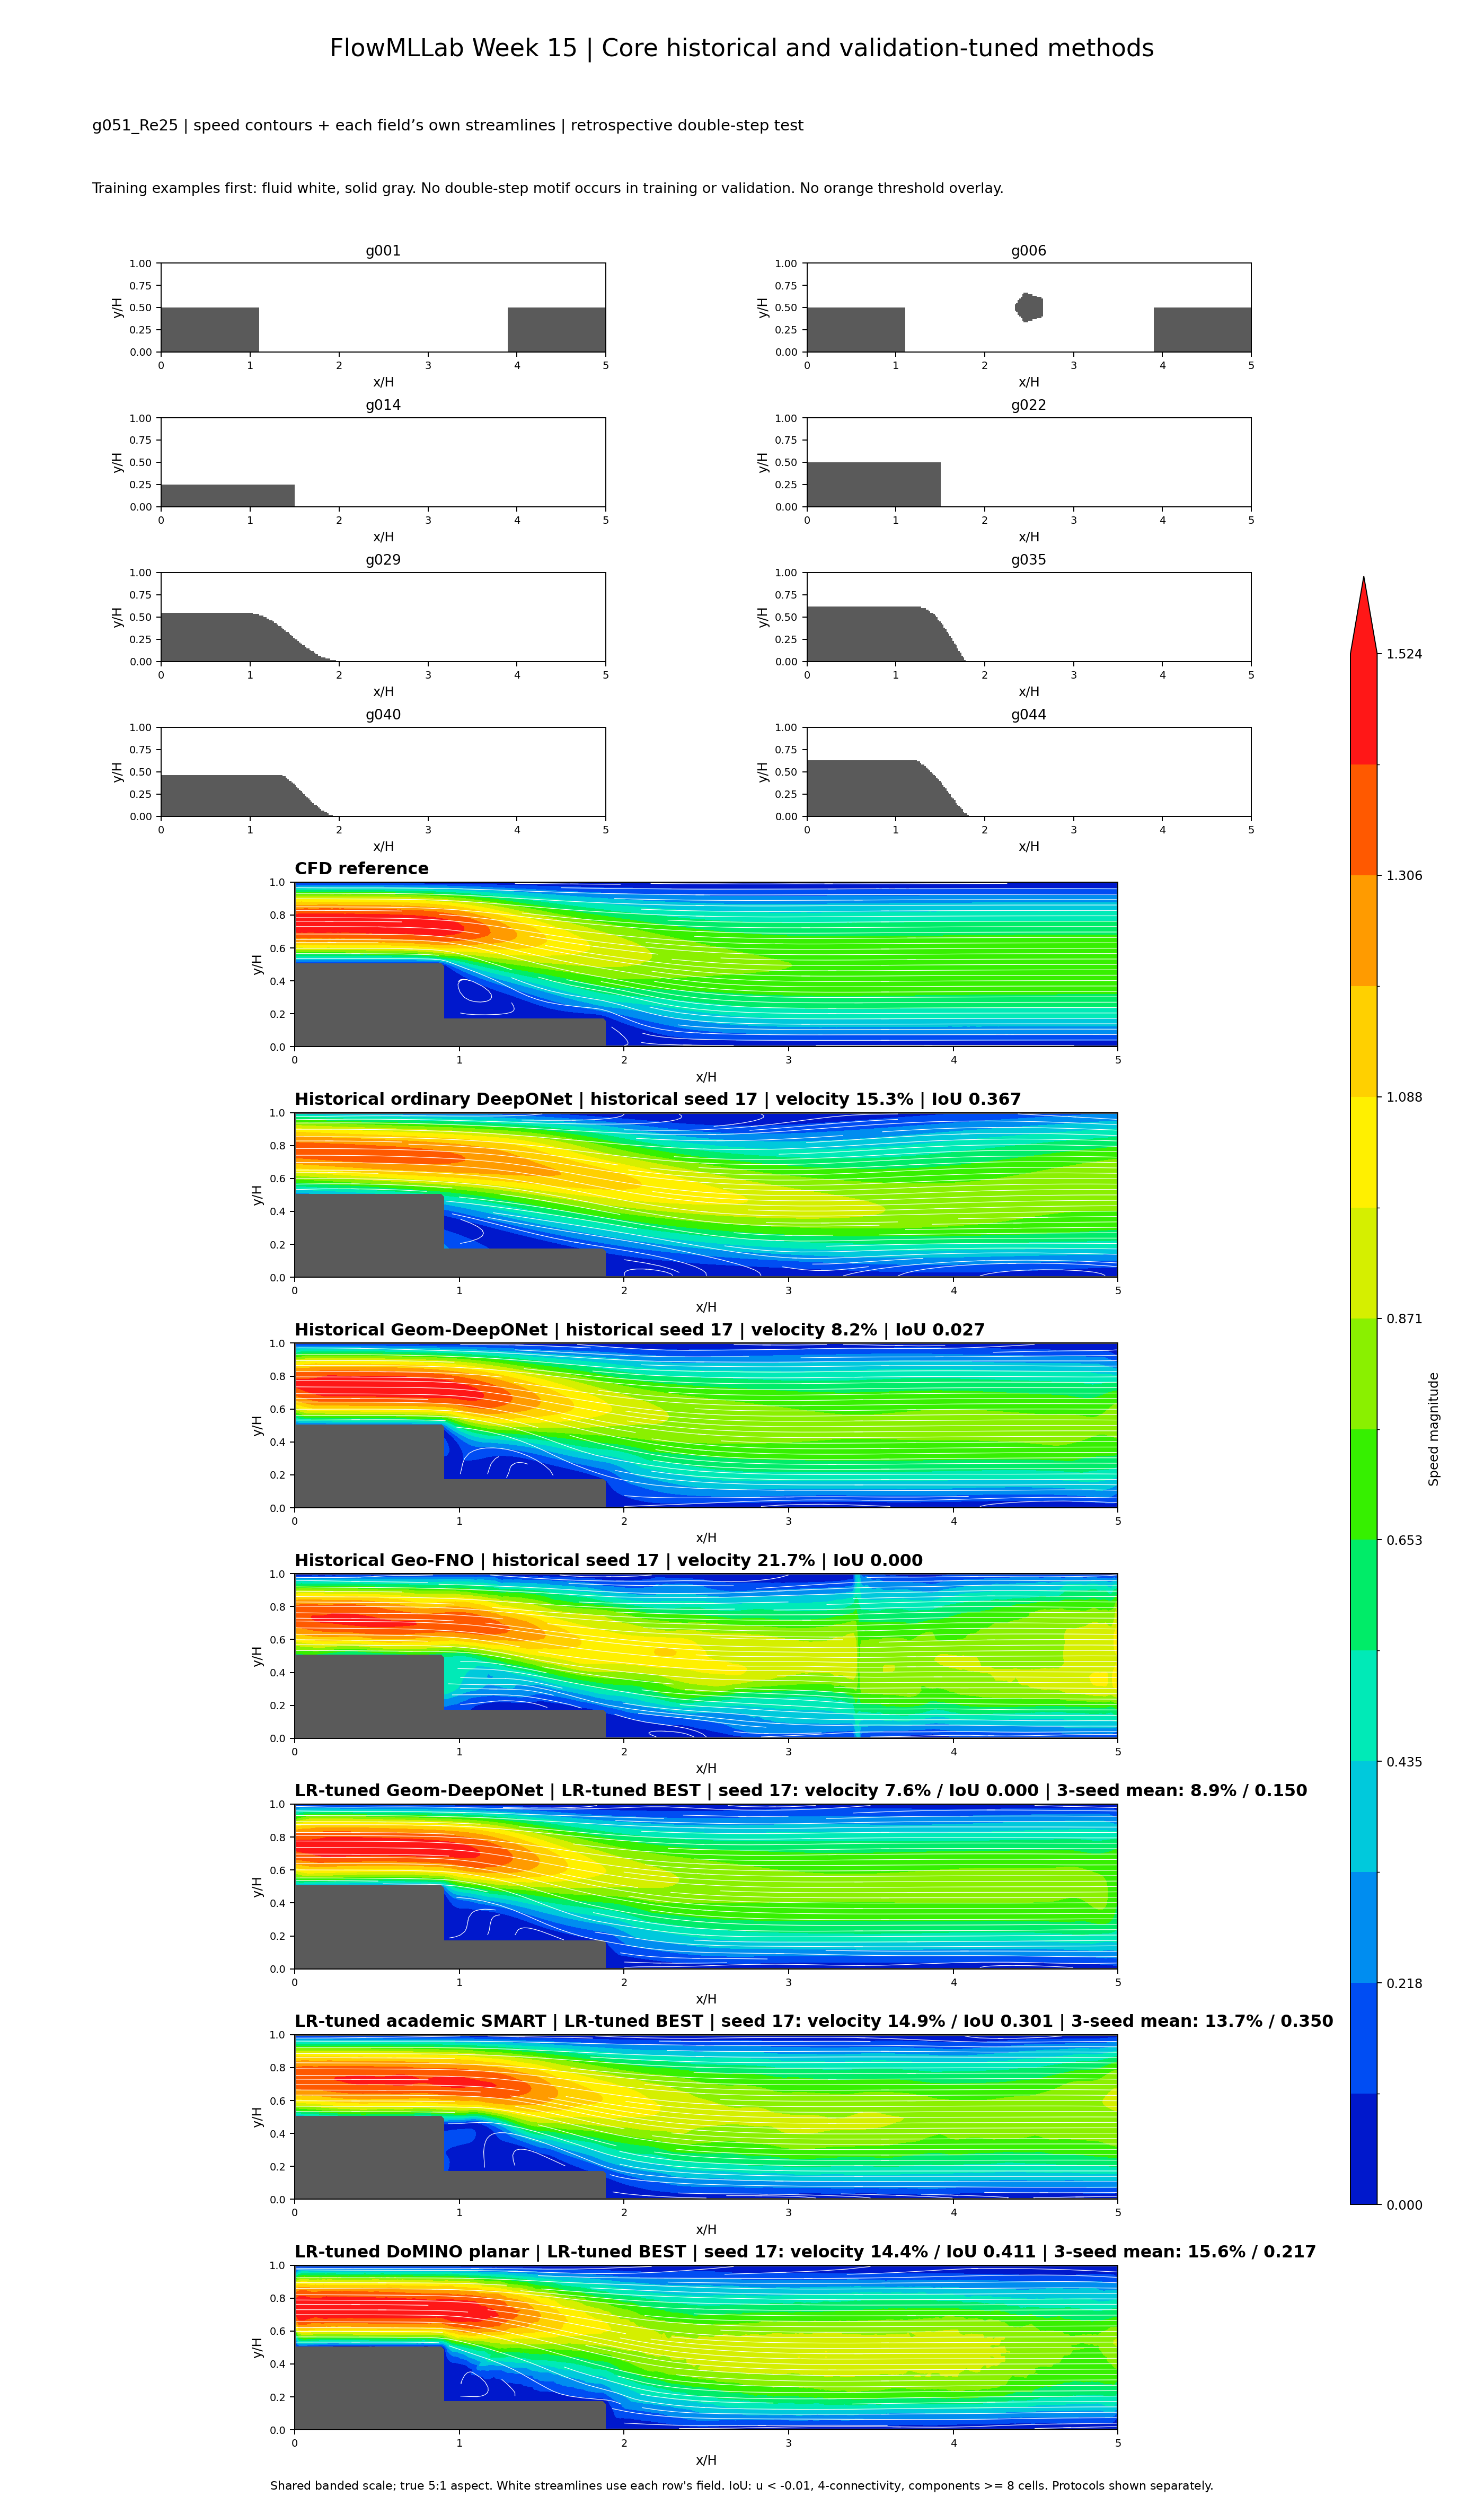

### core_g049_Re50.png

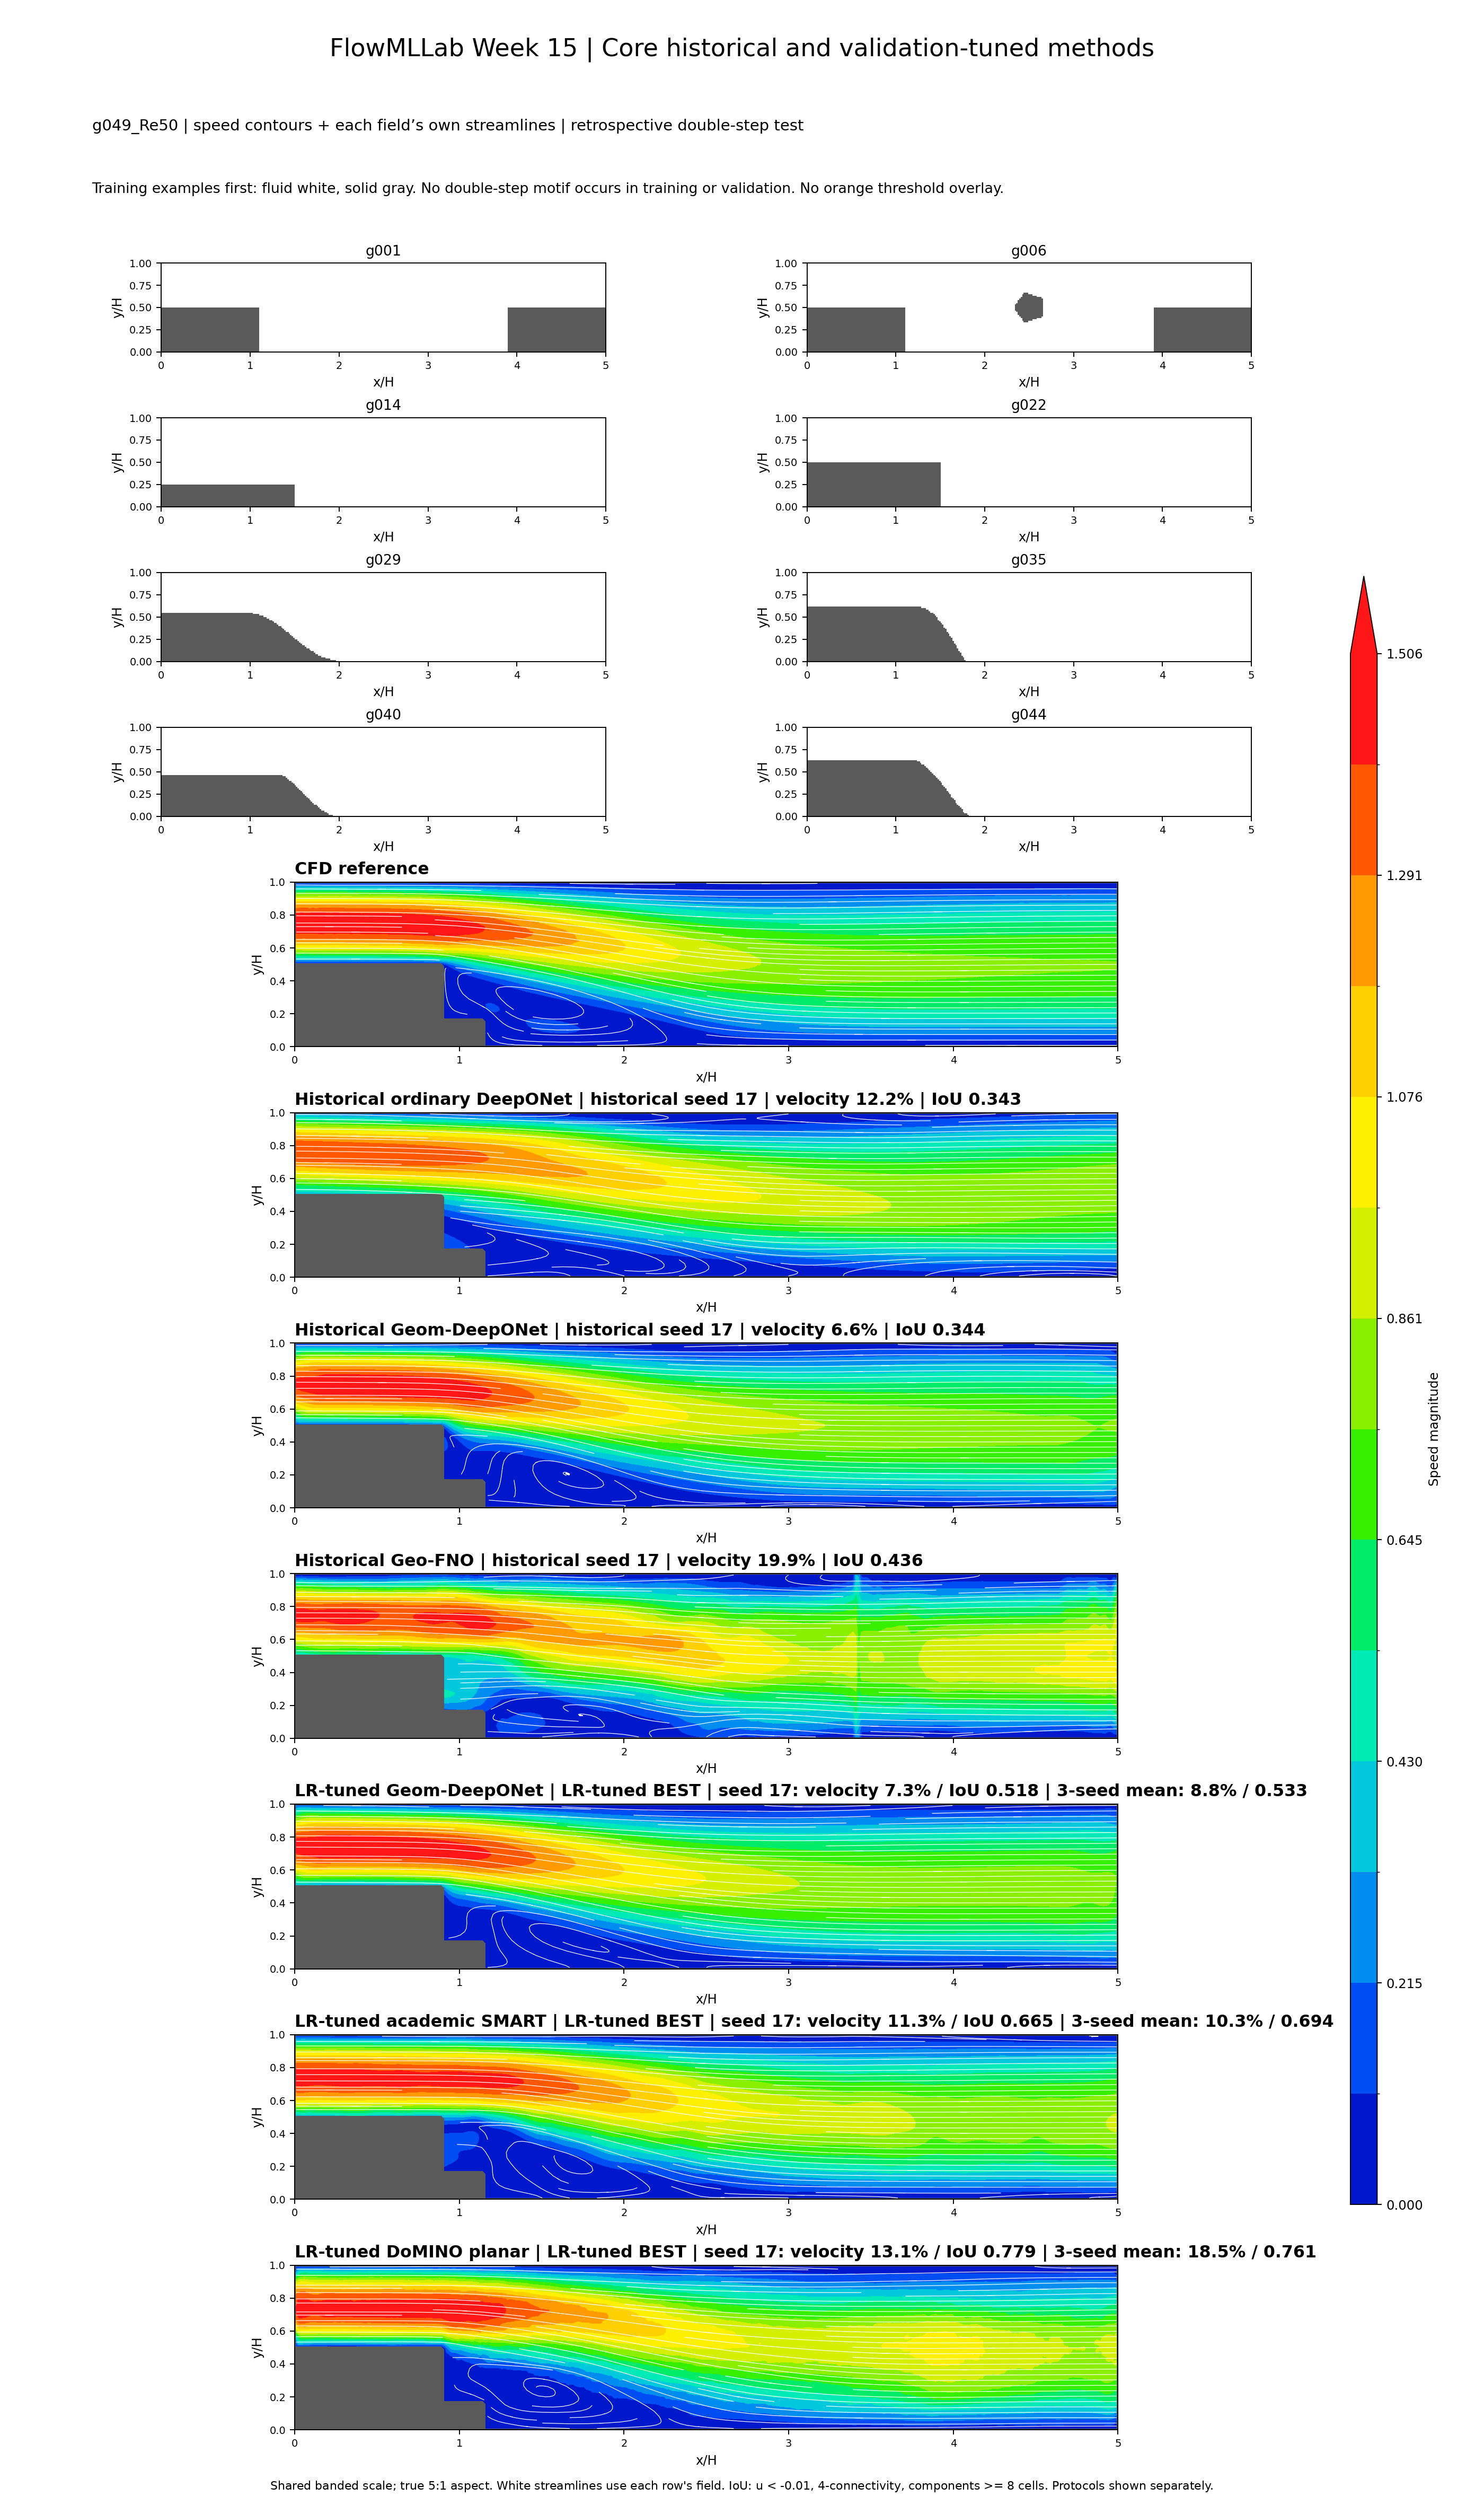

### core_g049_Re100.png

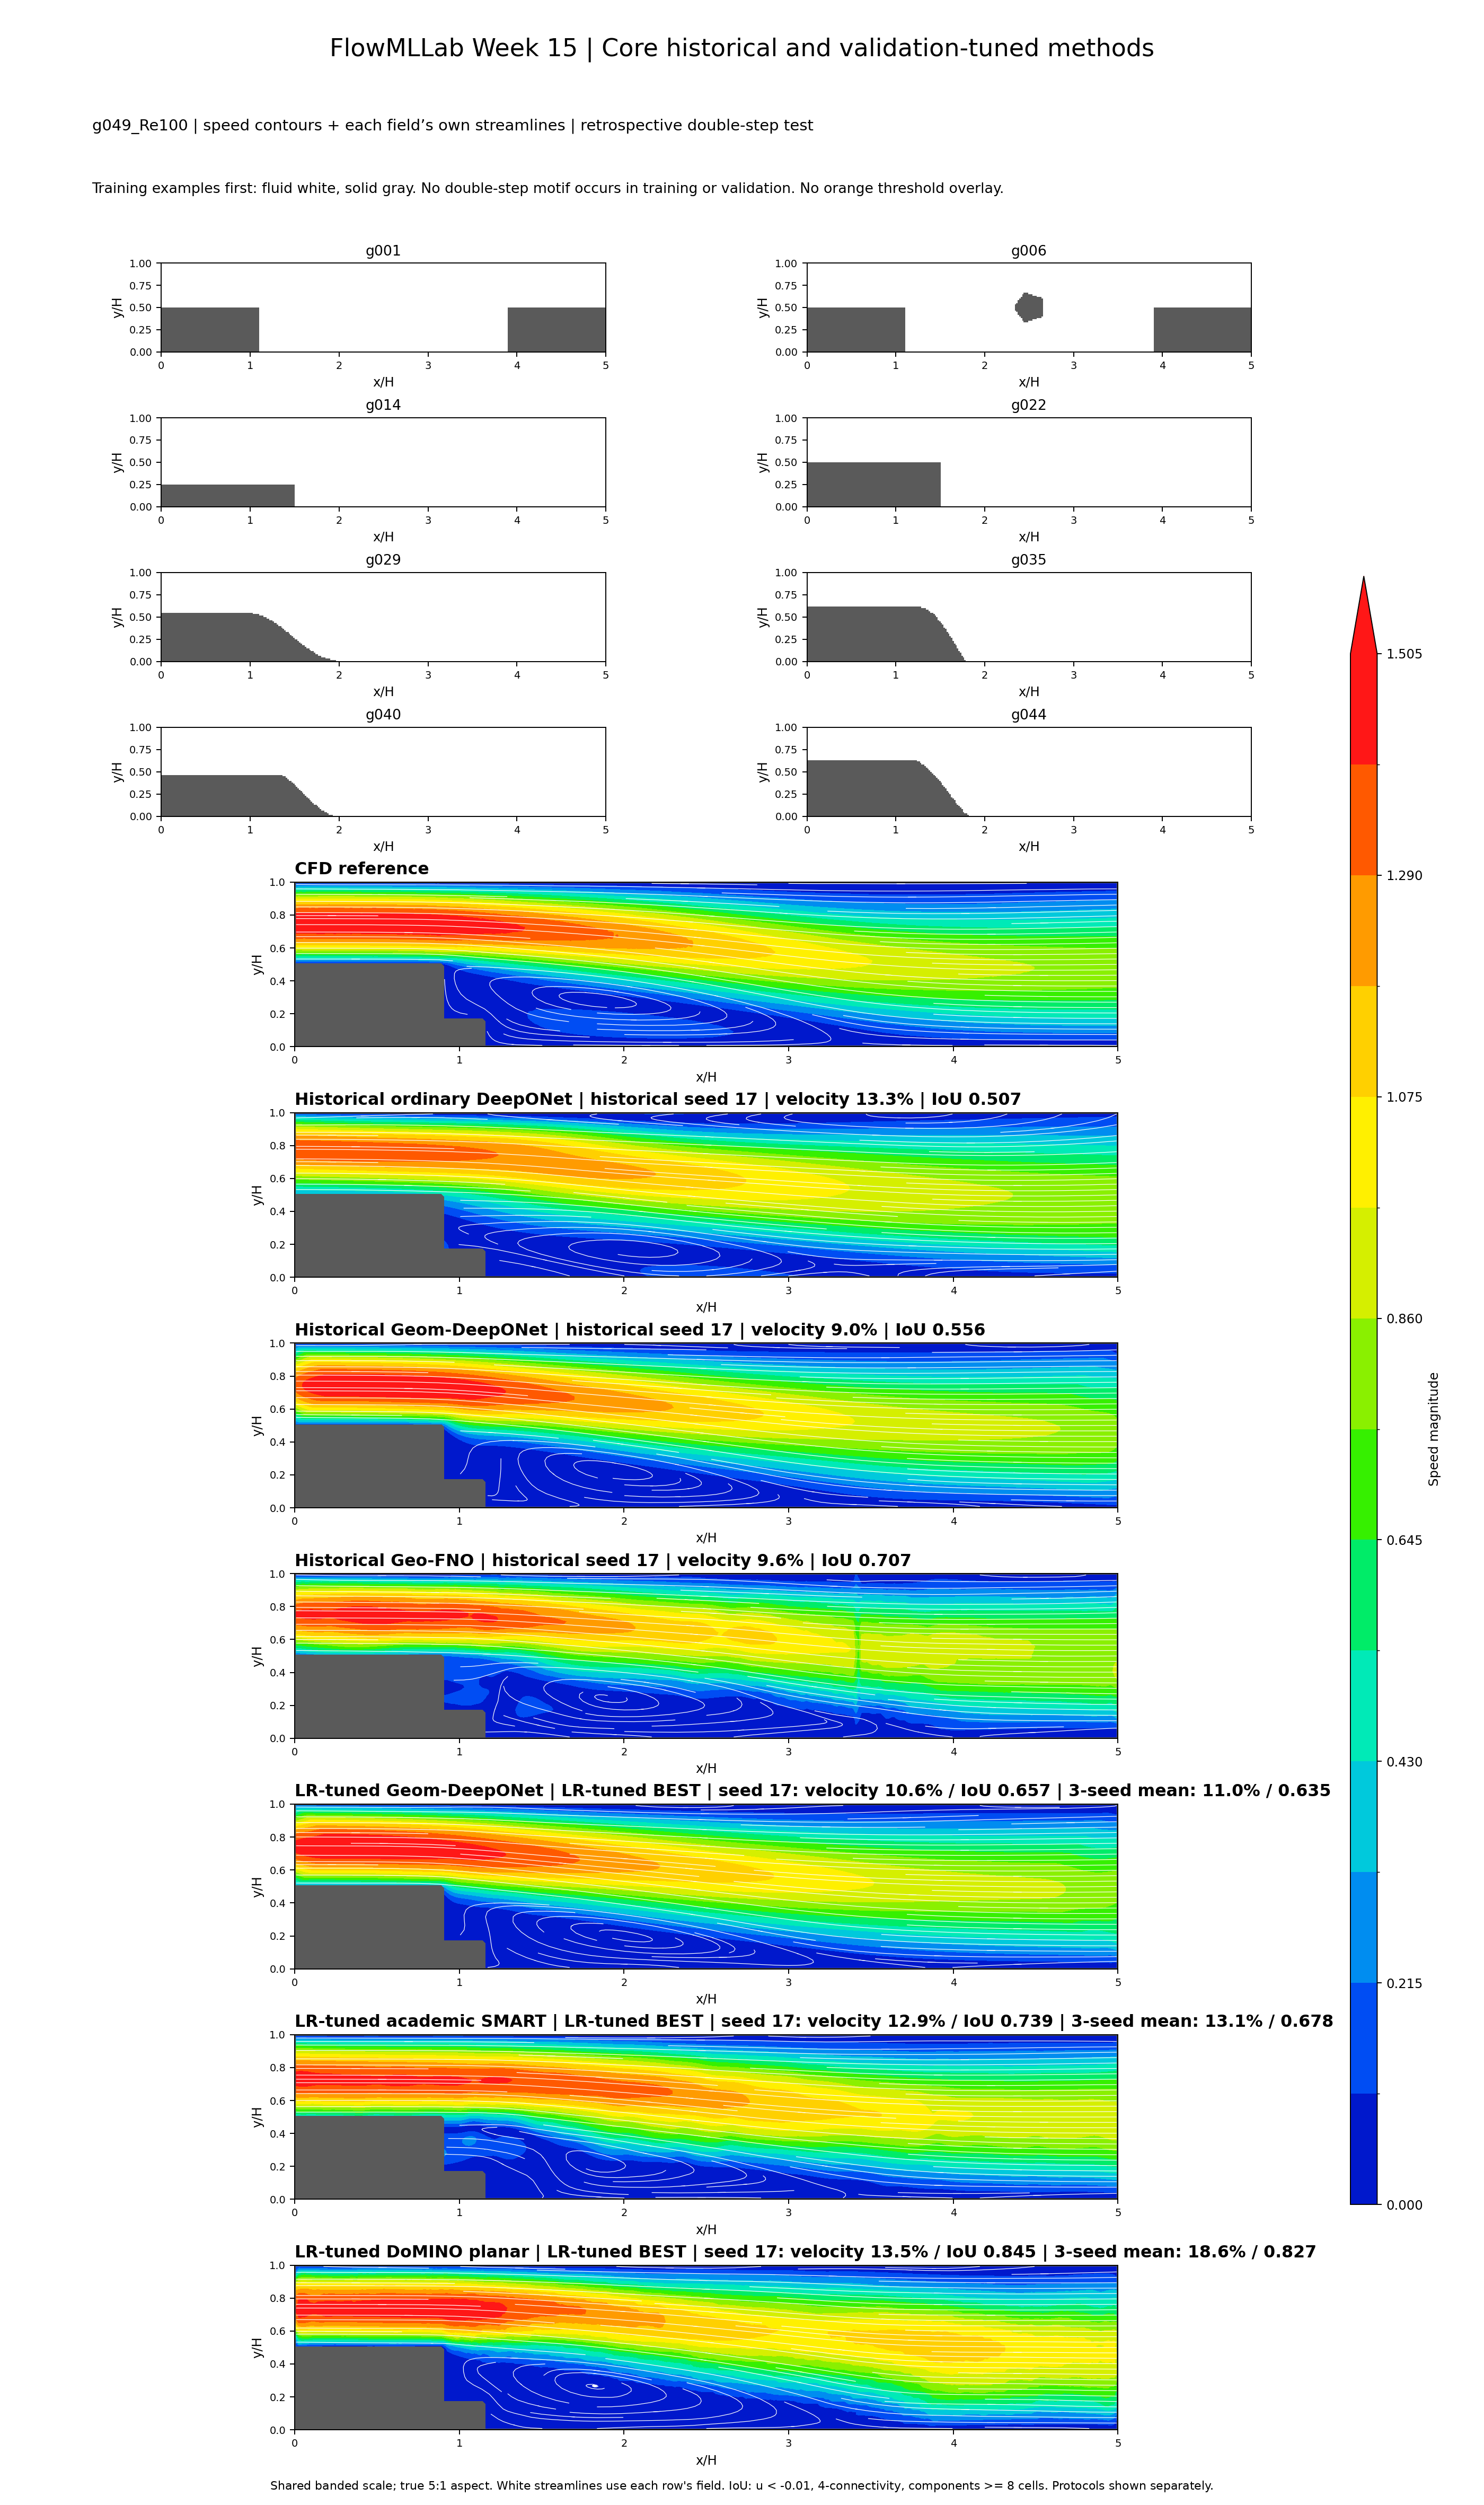

In [13]:
for f in ['core_g051_Re25.png','core_g049_Re50.png','core_g049_Re100.png']:
    display(Markdown('### '+f));display(Image(filename=str(FIGURES/f),width=1000))

## 14. Extended seven-row figures

The extended pages add matched-budget GeoTransolver, PhysicsX-inspired, and LIFT wall-feature rows. The latter two are transparent proxies and should be discussed as negative isolated-idea experiments.

### extended_g051_Re25.png

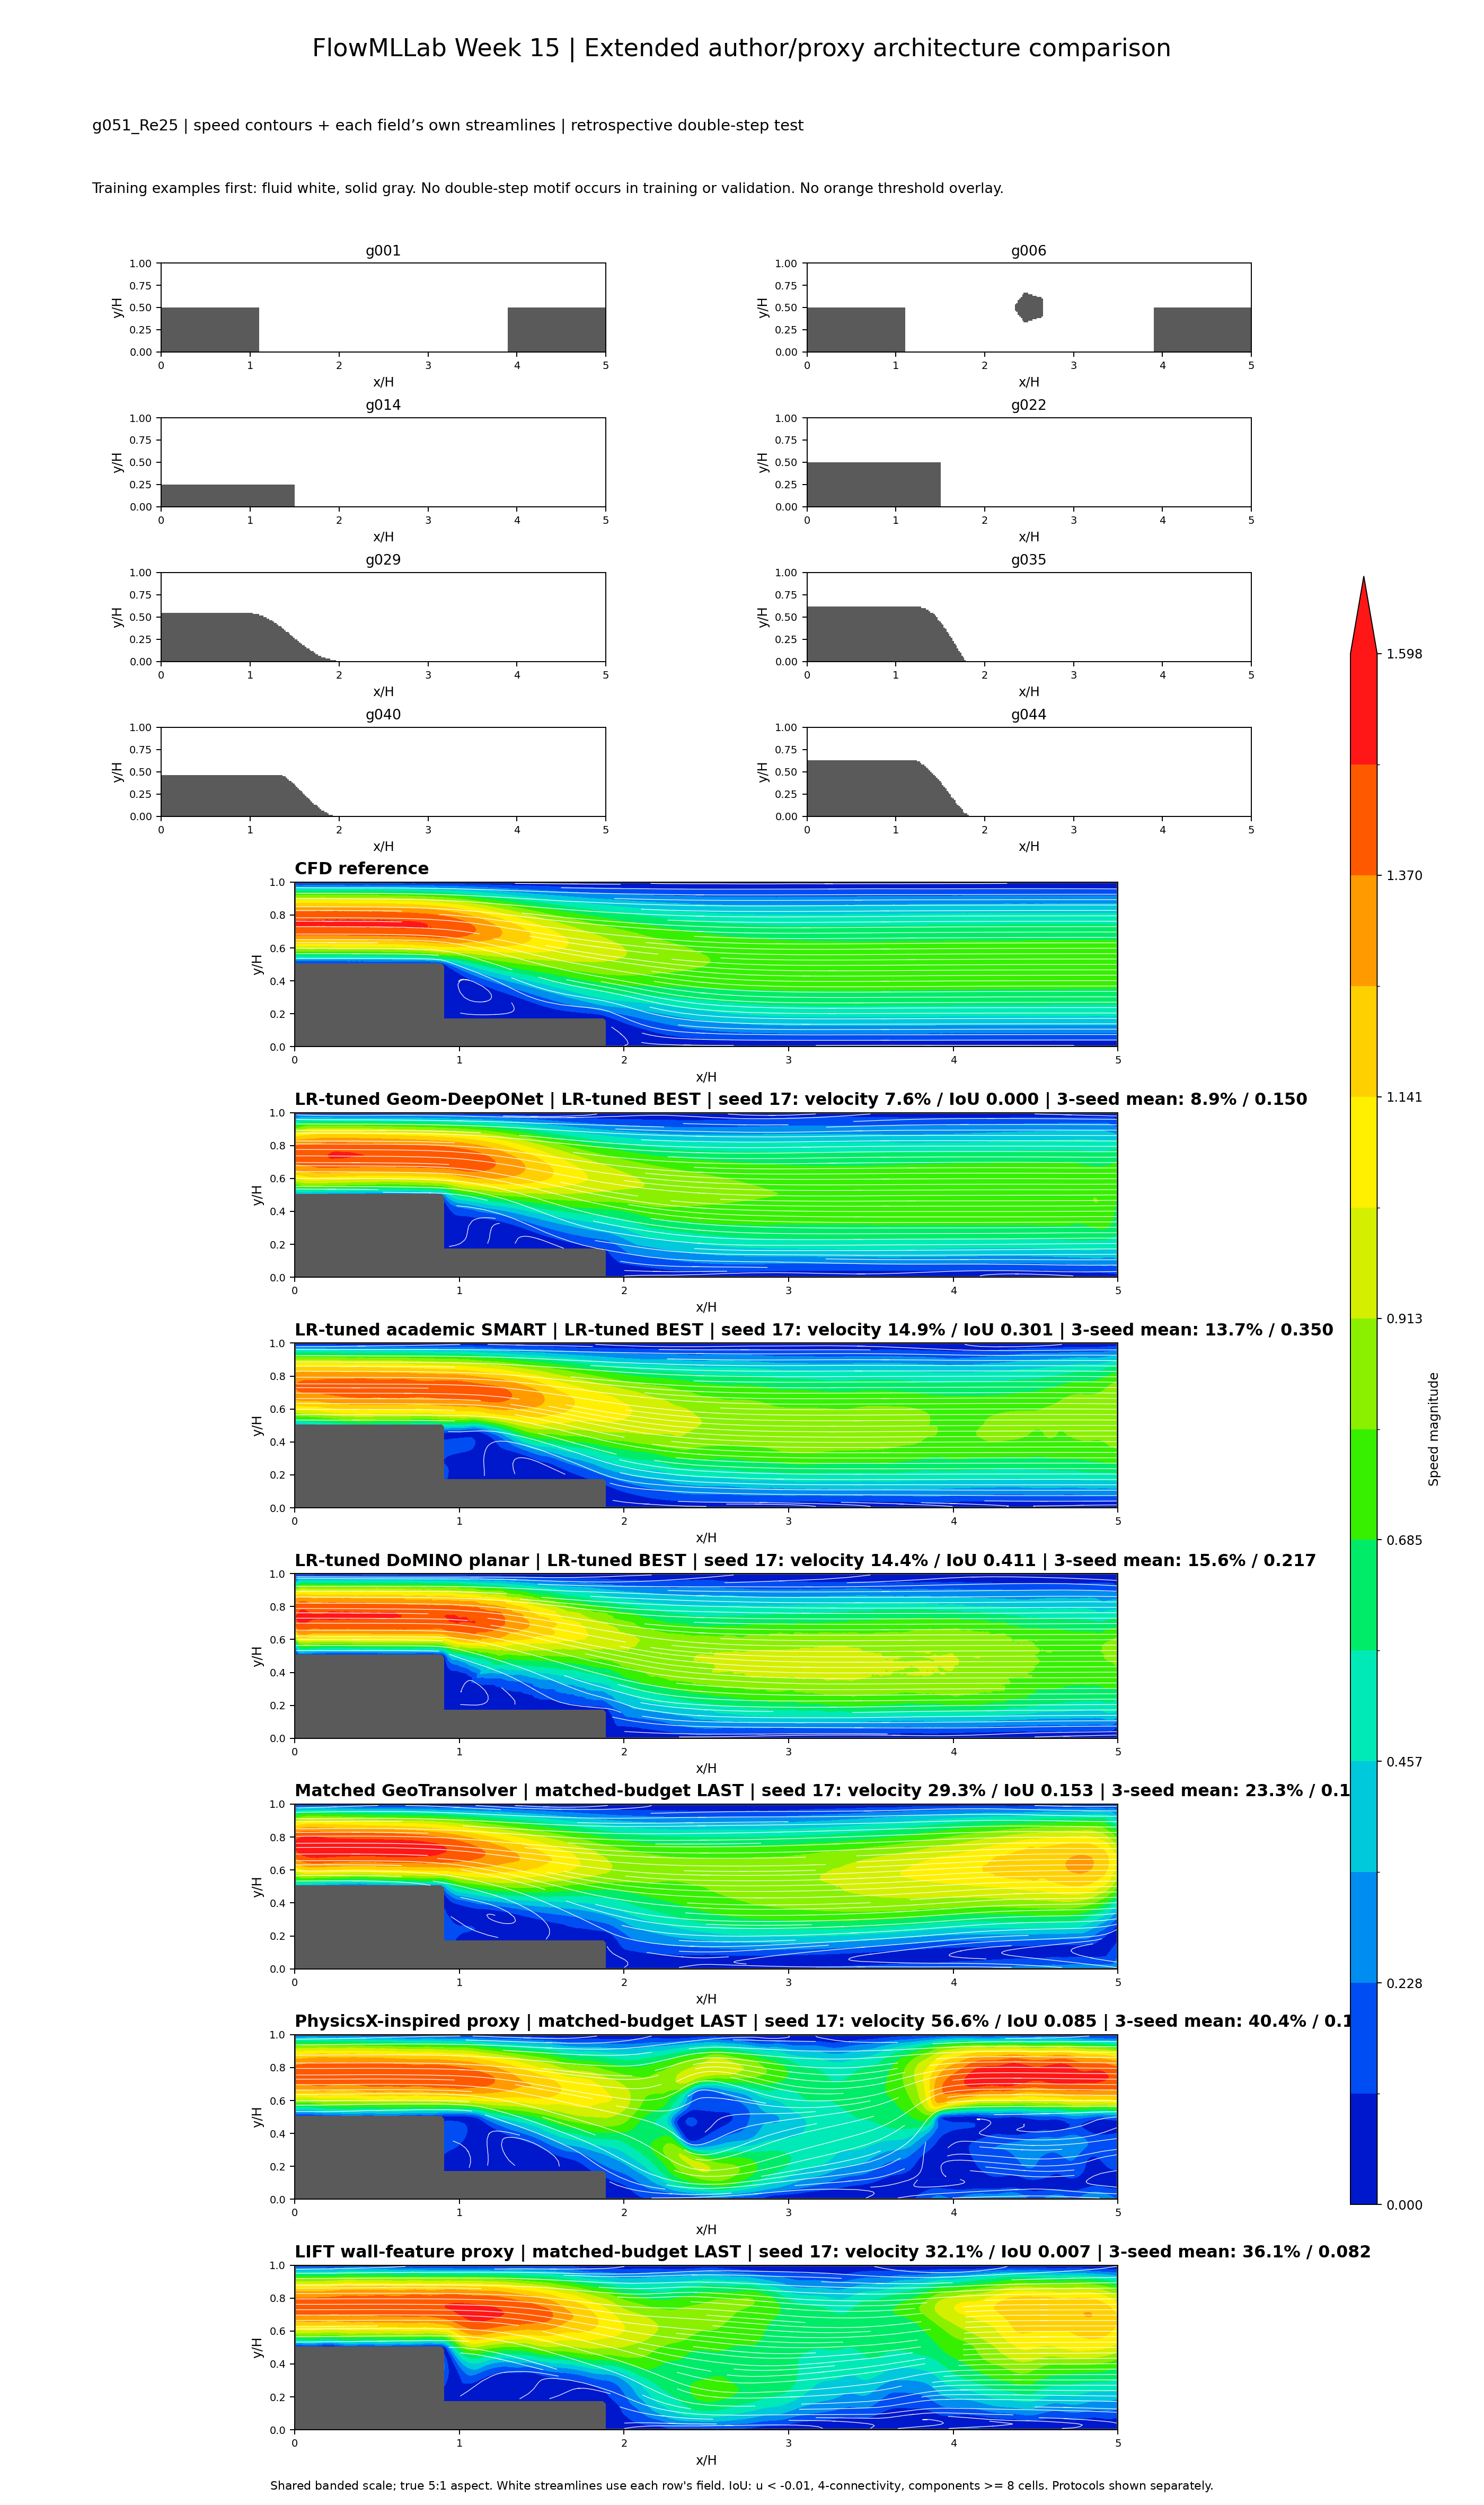

### extended_g049_Re50.png

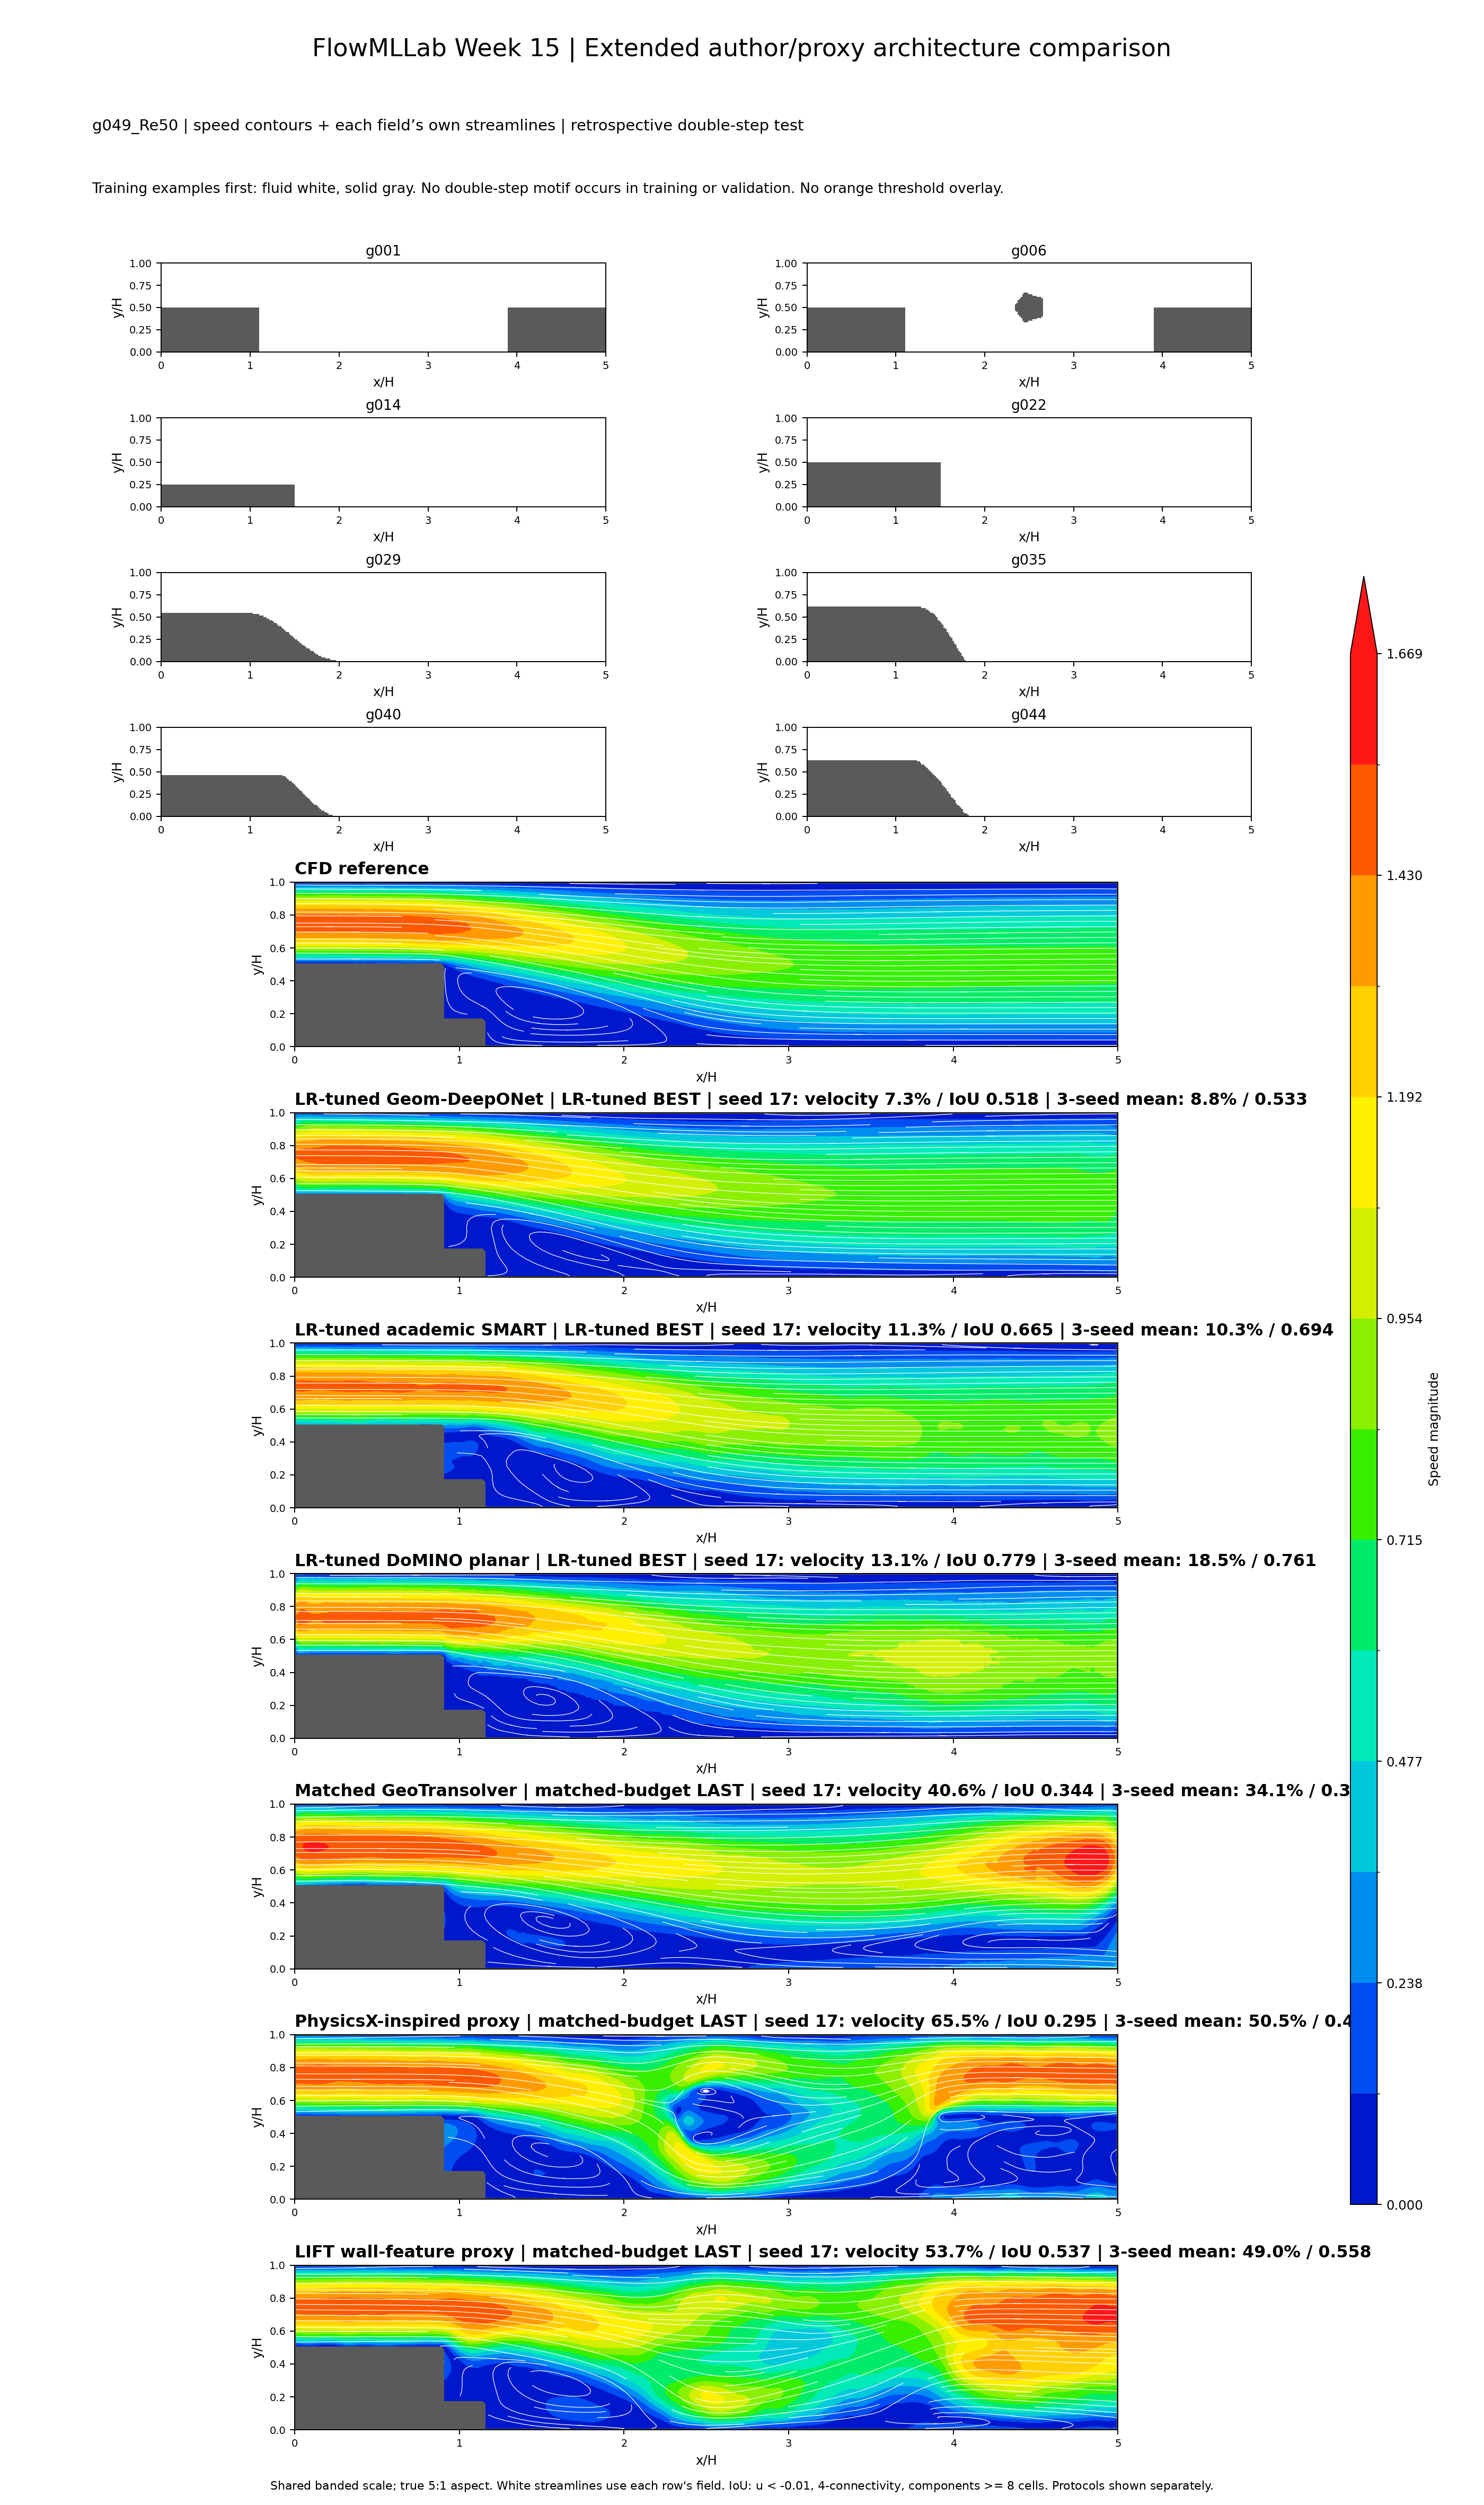

### extended_g049_Re100.png

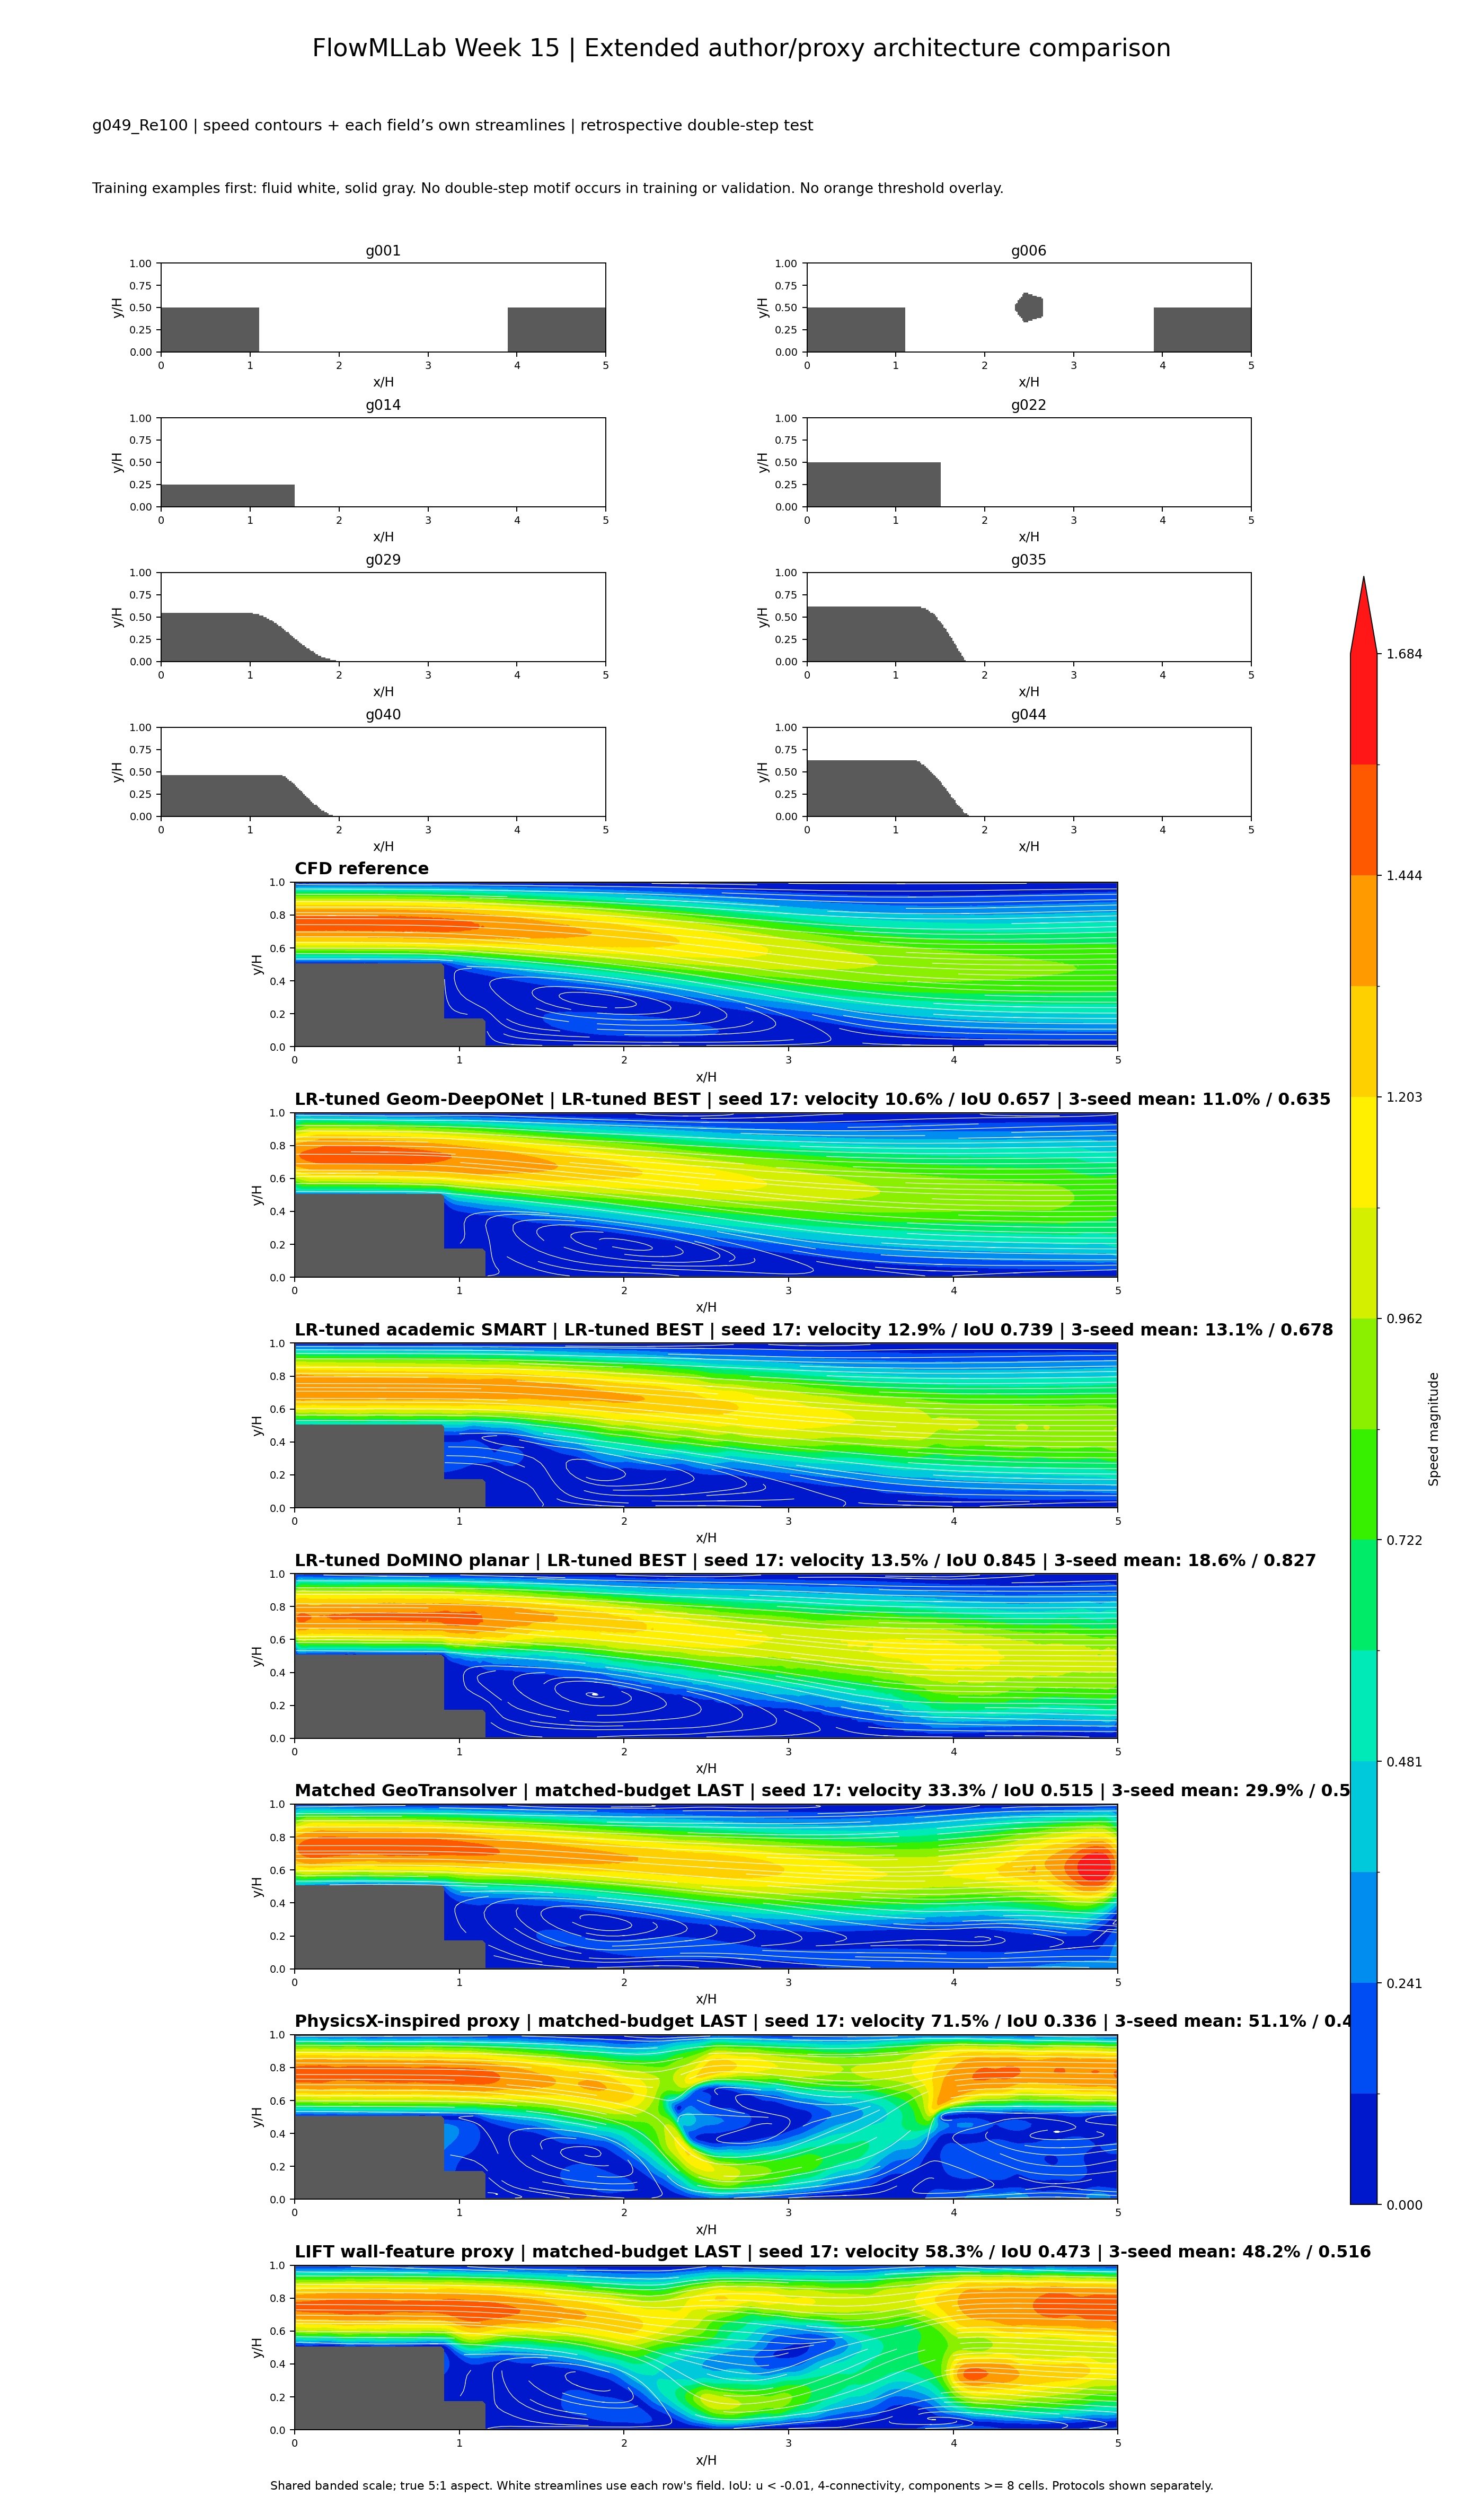

In [14]:
for f in ['extended_g051_Re25.png','extended_g049_Re50.png','extended_g049_Re100.png']:
    display(Markdown('### '+f));display(Image(filename=str(FIGURES/f),width=1000))

## 15. Figure provenance

In [15]:
prov=json.load(open(FIGURES/'figure_provenance.json'));assert len(prov)==6
for item in prov:assert sha(FIGURES/item['figure'])==item['sha256']
pd.DataFrame([{k:v for k,v in x.items() if k not in ['inputs']}|{'input_arrays':len(x['inputs'])} for x in prov])

,figure,sha256,case,group,training_geometry_ids,input_arrays
0,core_g051_Re25.png,133cadd8048c9edcb110f44d545d5685af469477e36188...,g051_Re25,core,"[1, 6, 14, 22, 29, 35, 40, 44]",6
1,extended_g051_Re25.png,efcbaa8202140a0571b690efaf9984e7b53f1fc0845bcd...,g051_Re25,extended,"[1, 6, 14, 22, 29, 35, 40, 44]",6
2,core_g049_Re50.png,c7f601801f84732eb3747dff33ceef2a8aede3869b96cb...,g049_Re50,core,"[1, 6, 14, 22, 29, 35, 40, 44]",6
3,extended_g049_Re50.png,17873d467b6b3f50a7c8ea209bb89865f374e99e5d5002...,g049_Re50,extended,"[1, 6, 14, 22, 29, 35, 40, 44]",6
4,core_g049_Re100.png,4acf28fb4b79af751ad6c1a8baee2a61de0ba7b5aadf7f...,g049_Re100,core,"[1, 6, 14, 22, 29, 35, 40, 44]",6
5,extended_g049_Re100.png,3ab78c068d1958ad763cf9f1d24a6abddb4989e4b1dc6f...,g049_Re100,extended,"[1, 6, 14, 22, 29, 35, 40, 44]",6


## 16. Pressure convention caution

The stored third channel is independently mean-centered for metrics. The original case setup is not available to prove the earlier label \(p^*=\mathrm{Re}p\), and the arrays do not support that scaling. Therefore this notebook uses the neutral label `stored pressure channel`.

Do not interpret absolute offsets or claim force accuracy from the centered field alone.

## 17. What improved and what worsened?

- Geom: tuning improves global velocity strongly and raises IoU, approaching the historical field checkpoint.
- SMART: tuning improves global field accuracy and yields higher IoU than tuned Geom, but reverse magnitude overshoot increases.
- DoMINO: tuning selects better validation behavior and the highest test IoU, but global velocity is worse than its earlier 3e-4 result.
- GeoTransolver and the proxies were not included in the new LR sweep; their displayed results remain the matched-budget 3e-4 runs.
- The common reverse-scale loss fails validation and remains a negative result.
- No method resolves the missing low-step/Re=25 coverage.

## 18. Student exercises

1. Modify the reverse threshold from -0.01 to -0.005 and -0.02 and compare absolute IoU.
2. Report component-count agreement separately from IoU.
3. Compute the ratio of predicted to CFD minimum u within reverse components.
4. Compare BEST and LAST checkpoints for each tuned model.
5. Design a family-holdout validation score that weights Re=25 equally.
6. Explain why a company-inspired proxy cannot validate a proprietary pretrained product.
7. List the CFD cases that would be required to remove the Reynolds/step-height confound.

## 19. Final scientific conclusion

The evidence does not identify one universally best geometry-generalizing neural operator. Historical Geom remains the best global field checkpoint. Tuned Geom is the best newly comparable global predictor. Tuned DoMINO detects the reverse footprint best. All methods weaken substantially in the uncovered Re=25 low-step regime.

The educational success of Week 15 is therefore not a perfect double-step prediction. It is a reproducible demonstration that architecture, geometry representation, optimization, data coverage, and vortex metrics must be evaluated together.